# FASE 3 — Entrenamiento

Entrenamos `DermaCNN` con:
- `CrossEntropyLoss` ponderada por clase (desbalance)
- Optimizador `AdamW` + scheduler `CosineAnnealingLR`
- Early stopping para evitar sobreajuste
- Checkpointing del mejor modelo (por F1-Macro en validación)
- Curvas de pérdida y métricas en tiempo real

## 1. Imports y configuración

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import time, os
from tqdm import tqdm
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score, confusion_matrix

# Módulos de fases anteriores
from pipeline import get_dataloaders, CLASS_NAMES, CLASS_WEIGHTS, NUM_CLASSES
from model import DermaCNN

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

Device : cuda
GPU    : NVIDIA GeForce RTX 3050 6GB Laptop GPU
VRAM   : 6.4 GB


## 2. Hiperparámetros

## 3. DataLoaders, Modelo, Loss, Optimizador

In [2]:
# fase3_config_v14.py
# v14 = fusiones correctas del taller + skip connections + pesos ajustados
#       + MÁS ÉPOCAS (150) porque v13 seguía mejorando en ep117
#
# model.py: NO cambia (fusiones correctas + skip connections)
# pipeline.py: pesos [1.50,1.20,1.10,2.20,0.90,0.48,0.89]
#
# Reemplaza solo pipeline.py y celdas 2, 3 y 6. Reiniciar kernel.

from pipeline import get_dataloaders, CLASS_NAMES, CLASS_WEIGHTS, NUM_CLASSES
from model import DermaCNN
import torch
import torch.nn as nn
import numpy as np
import time
from tqdm import tqdm
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def mixup_data(x, y, alpha=0.2):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    idx = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1 - lam) * x[idx], y, y[idx], lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

CONFIG = {
    'batch_size'   : 64,
    'num_epochs'   : 150,      # v13 llegó al límite de 120 aún mejorando
    'lr'           : 1e-3,
    'weight_decay' : 1e-5,
    'dropout'      : 0.25,
    'patience'     : 30,       # proporcional a las épocas
    'min_delta'    : 1e-4,
    'checkpoint'   : 'best_model_v14.pth',
    'num_workers'  : 0,
    'mixup_alpha'  : 0.2,
    'pct_start'    : 0.20,
}

train_loader, val_loader, test_loader = get_dataloaders(num_workers=CONFIG['num_workers'])

imgs, _ = next(iter(train_loader))
assert imgs.shape[-1] == 64
print(f'✅ Imágenes: {imgs.shape}')

model = DermaCNN(num_classes=NUM_CLASSES, dropout=CONFIG['dropout']).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'✅ Parámetros: {total_params:,}')
assert total_params > 495032, '❌ Verificar model.py con skip connections y fusiones correctas'

class_weights_tensor = torch.FloatTensor(CLASS_WEIGHTS).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=0.05)

optimizer = torch.optim.AdamW(model.parameters(),
                               lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay'])

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=CONFIG['lr'],
    steps_per_epoch=len(train_loader),
    epochs=CONFIG['num_epochs'],
    pct_start=CONFIG['pct_start'],
    anneal_strategy='cos',
)

print(f'Device     : {DEVICE}')
print(f'Parámetros : {total_params:,}')
print(f'Checkpoint : {CONFIG["checkpoint"]}')
print(f'Épocas     : {CONFIG["num_epochs"]} (patience={CONFIG["patience"]})')
print()
print('v14 vs v13:')
print('  Épocas:     120 → 150  (v13 llegó a ep120 aún en mejora)')
print('  Patience:   25  → 30')
print('  actinic[0]: 1.20→1.50  F1=0.44, clase más rezagada')
print('  basal[1]:   1.40→1.20  rec=0.66 OK, reducir FP (prec=0.49)')
print('  benign[2]:  1.00→1.10  leve boost')
print('  dermato[3]: 2.00→2.20  rec=0.52 mejoró pero sigue bajo')
print('  melanoma[4]:1.10→0.90  prec=0.42 con rec=0.65 → frenar FP')
print('  model.py: SIN CAMBIOS (fusiones correctas + skip connections)')
print()

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, all_preds, all_labels, all_probs = 0.0, [], [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits = model(imgs)
            loss   = criterion(logits, labels)
            total_loss += loss.item() * imgs.size(0)
            probs  = torch.softmax(logits, dim=1)
            all_preds.extend(probs.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    ap = np.array(all_preds); al = np.array(all_labels); apr = np.array(all_probs)
    return (total_loss/len(loader.dataset),
            accuracy_score(al, ap),
            f1_score(al, ap, average='macro', zero_division=0),
            roc_auc_score(al, apr, multi_class='ovr', average='macro'),
            ap, al, apr)

class EarlyStopping:
    def __init__(self, patience=30, min_delta=1e-4, path='best.pth'):
        self.patience=patience; self.min_delta=min_delta; self.path=path
        self.counter=0; self.best_score=None; self.stop=False
    def __call__(self, score, model):
        if self.best_score is None:
            self.best_score=score; self._save(model, score)
        elif score < self.best_score + self.min_delta:
            self.counter += 1
            print(f'     EarlyStopping: {self.counter}/{self.patience}')
            if self.counter >= self.patience: self.stop = True
        else:
            self._save(model, score); self.best_score=score; self.counter=0
    def _save(self, model, score):
        torch.save(model.state_dict(), self.path)
        print(f'     ✅ Checkpoint guardado (F1={score:.4f})')

early_stopping = EarlyStopping(patience=CONFIG['patience'],
                                min_delta=CONFIG['min_delta'],
                                path=CONFIG['checkpoint'])

print('Iniciando entrenamiento v14...')
print('='*70)
start_time = time.time()

for epoch in range(1, CONFIG['num_epochs'] + 1):
    model.train()
    train_loss, train_preds, train_labels_ep = 0.0, [], []
    pbar = tqdm(train_loader, desc=f'Epoch {epoch:03d}/{CONFIG["num_epochs"]}',
                leave=False, ncols=80)
    for imgs, labels in pbar:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        imgs_mix, y_a, y_b, lam = mixup_data(imgs, labels, CONFIG['mixup_alpha'])
        optimizer.zero_grad()
        logits = model(imgs_mix)
        loss   = mixup_criterion(criterion, logits, y_a, y_b, lam)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        train_loss += loss.item() * imgs.size(0)
        train_preds.extend(logits.argmax(dim=1).cpu().numpy())
        train_labels_ep.extend(labels.cpu().numpy())
        pbar.set_postfix({'loss': f'{loss.item():.3f}'})

    t_loss = train_loss/len(train_loader.dataset)
    t_acc  = accuracy_score(train_labels_ep, train_preds)
    t_f1   = f1_score(train_labels_ep, train_preds, average='macro', zero_division=0)
    v_loss, v_acc, v_f1, v_auc, _, _, _ = evaluate(model, val_loader, criterion, DEVICE)
    current_lr = optimizer.param_groups[0]['lr']
    elapsed = (time.time() - start_time) / 60

    print(f'Ep {epoch:03d} | TLoss={t_loss:.4f} Tacc={t_acc:.3f} TF1={t_f1:.3f} | '
          f'VLoss={v_loss:.4f} Vacc={v_acc:.3f} VF1={v_f1:.3f} VAUC={v_auc:.3f} | '
          f'LR={current_lr:.2e} | {elapsed:.1f}min')

    early_stopping(v_f1, model)
    if early_stopping.stop:
        print(f'\n⛔ Early stopping en época {epoch}')
        break

total_time = (time.time() - start_time) / 60
print('='*70)
print(f'Entrenamiento finalizado en {total_time:.1f} min')
print(f'Mejor F1-Macro en validación: {early_stopping.best_score:.4f}')

Using downloaded and verified file: C:\Users\isape\.medmnist\dermamnist.npz
Using downloaded and verified file: C:\Users\isape\.medmnist\dermamnist.npz
Using downloaded and verified file: C:\Users\isape\.medmnist\dermamnist.npz
✅ Imágenes: torch.Size([64, 3, 64, 64])
✅ Parámetros: 510,057
Device     : cuda
Parámetros : 510,057
Checkpoint : best_model_v14.pth
Épocas     : 150 (patience=30)

v14 vs v13:
  Épocas:     120 → 150  (v13 llegó a ep120 aún en mejora)
  Patience:   25  → 30
  actinic[0]: 1.20→1.50  F1=0.44, clase más rezagada
  basal[1]:   1.40→1.20  rec=0.66 OK, reducir FP (prec=0.49)
  benign[2]:  1.00→1.10  leve boost
  dermato[3]: 2.00→2.20  rec=0.52 mejoró pero sigue bajo
  melanoma[4]:1.10→0.90  prec=0.42 con rec=0.65 → frenar FP
  model.py: SIN CAMBIOS (fusiones correctas + skip connections)

Iniciando entrenamiento v14...


Ep 001 | TLoss=1.9449 Tacc=0.193 TF1=0.153 | VLoss=1.7516 Vacc=0.455 VF1=0.251 VAUC=0.787 | LR=4.26e-05 | 0.8min
     ✅ Checkpoint guardado (F1=0.2510)


Ep 002 | TLoss=1.7837 Tacc=0.276 TF1=0.210 | VLoss=1.6693 Vacc=0.492 VF1=0.313 VAUC=0.836 | LR=5.05e-05 | 1.7min
     ✅ Checkpoint guardado (F1=0.3135)


Ep 003 | TLoss=1.7195 Tacc=0.308 TF1=0.227 | VLoss=1.5870 Vacc=0.534 VF1=0.346 VAUC=0.829 | LR=6.35e-05 | 2.5min
     ✅ Checkpoint guardado (F1=0.3458)


Ep 004 | TLoss=1.6705 Tacc=0.342 TF1=0.250 | VLoss=1.5669 Vacc=0.533 VF1=0.342 VAUC=0.865 | LR=8.15e-05 | 3.3min
     EarlyStopping: 1/30


...

Ep 146 | TLoss=0.8203 Tacc=0.526 TF1=0.454 | VLoss=1.1792 Vacc=0.750 VF1=0.581 VAUC=0.905 | LR=2.73e-06 | 114.8min
     EarlyStopping: 19/30


Ep 147 | TLoss=0.8593 Tacc=0.561 TF1=0.503 | VLoss=1.2069 Vacc=0.738 VF1=0.588 VAUC=0.898 | LR=1.54e-06 | 115.5min
     EarlyStopping: 20/30


Ep 148 | TLoss=0.8350 Tacc=0.617 TF1=0.560 | VLoss=1.1846 Vacc=0.743 VF1=0.585 VAUC=0.902 | LR=6.83e-07 | 116.1min
     EarlyStopping: 21/30


Ep 149 | TLoss=0.8636 Tacc=0.631 TF1=0.592 | VLoss=1.1720 Vacc=0.751 VF1=0.582 VAUC=0.905 | LR=1.72e-07 | 116.7min
     EarlyStopping: 22/30


Ep 150 | TLoss=0.8126 Tacc=0.581 TF1=0.528 | VLoss=1.1657 Vacc=0.747 VF1=0.579 VAUC=0.908 | LR=4.01e-09 | 117.4min
     EarlyStopping: 23/30
Entrenamiento finalizado en 117.4 min
Mejor F1-Macro en validación: 0.6019


## 4. Funciones de evaluación

In [3]:
def evaluate(model, loader, criterion, device):
    """
    Evalúa el modelo en un dataloader.
    Retorna: loss, accuracy, f1_macro, auc_macro, all_preds, all_labels, all_probs
    """
    model.eval()
    total_loss = 0.0
    all_preds  = []
    all_labels = []
    all_probs  = []   # probabilidades para AUC

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits = model(imgs)
            loss   = criterion(logits, labels)
            total_loss += loss.item() * imgs.size(0)

            probs  = torch.softmax(logits, dim=1)
            preds  = probs.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)

    avg_loss = total_loss / len(loader.dataset)
    acc      = accuracy_score(all_labels, all_preds)
    f1       = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    auc      = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')

    return avg_loss, acc, f1, auc, all_preds, all_labels, all_probs


print('✅ Función evaluate() definida')

✅ Función evaluate() definida


## 5. Early Stopping

In [4]:
class EarlyStopping:
    """
    Detiene el entrenamiento si la métrica de validación
    no mejora por `patience` épocas consecutivas.
    Guarda el mejor modelo automáticamente.
    """
    def __init__(self, patience=12, min_delta=1e-4, path='best_model.pth', verbose=True):
        self.patience   = patience
        self.min_delta  = min_delta
        self.path       = path
        self.verbose    = verbose
        self.counter    = 0
        self.best_score = None
        self.stop       = False

    def __call__(self, score, model):
        if self.best_score is None:
            self.best_score = score
            self._save(model, score)
        elif score < self.best_score + self.min_delta:
            self.counter += 1
            if self.verbose:
                print(f'     EarlyStopping: {self.counter}/{self.patience}')
            if self.counter >= self.patience:
                self.stop = True
        else:
            self._save(model, score)
            self.best_score = score
            self.counter    = 0

    def _save(self, model, score):
        torch.save(model.state_dict(), self.path)
        if self.verbose:
            print(f'     ✅ Checkpoint guardado (F1={score:.4f})')


print('✅ EarlyStopping definido')

✅ EarlyStopping definido


## 6. Loop de Entrenamiento

## 7. Curvas de Entrenamiento

In [5]:
epochs_ran = len(history['train_loss'])
ep_range   = range(1, epochs_ran + 1)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Curvas de Entrenamiento — DermaCNN', fontsize=15, fontweight='bold')

# Loss
ax = axes[0][0]
ax.plot(ep_range, history['train_loss'], label='Train', color='steelblue')
ax.plot(ep_range, history['val_loss'],   label='Val',   color='tomato')
ax.set_title('Loss')
ax.set_xlabel('Época')
ax.legend()
ax.grid(alpha=0.3)

# Accuracy
ax = axes[0][1]
ax.plot(ep_range, history['train_acc'], label='Train', color='steelblue')
ax.plot(ep_range, history['val_acc'],   label='Val',   color='tomato')
ax.axhline(0.69, color='green', linestyle='--', alpha=0.7, label='Target (0.69)')
ax.set_title('Accuracy')
ax.set_xlabel('Época')
ax.legend()
ax.grid(alpha=0.3)

# F1-Macro
ax = axes[1][0]
ax.plot(ep_range, history['train_f1'], label='Train', color='steelblue')
ax.plot(ep_range, history['val_f1'],   label='Val',   color='tomato')
ax.axhline(0.65, color='green', linestyle='--', alpha=0.7, label='Target (0.65)')
ax.set_title('F1-Score Macro')
ax.set_xlabel('Época')
ax.legend()
ax.grid(alpha=0.3)

# AUC + LR
ax = axes[1][1]
ax.plot(ep_range, history['val_auc'], label='Val AUC', color='purple')
ax.axhline(0.90, color='green', linestyle='--', alpha=0.7, label='Target (0.90)')
ax2 = ax.twinx()
ax2.plot(ep_range, history['lr'], color='gray', linestyle=':', alpha=0.6, label='LR')
ax2.set_ylabel('Learning Rate', color='gray')
ax.set_title('AUC (val) + Learning Rate')
ax.set_xlabel('Época')
ax.legend(loc='lower left')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('curvas_entrenamiento.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: curvas_entrenamiento.png')

NameError: name 'history' is not defined

## 8. Evaluación Final en Test Set

In [6]:
# Cargar el mejor modelo guardado
model.load_state_dict(torch.load(CONFIG['checkpoint'], map_location=DEVICE))
print(f'Modelo cargado desde: {CONFIG["checkpoint"]}')

# Evaluar en Test Set
test_loss, test_acc, test_f1, test_auc, test_preds, test_labels, test_probs = evaluate(
    model, test_loader, criterion, DEVICE
)

print()
print('='*50)
print('  RESULTADOS FINALES — TEST SET')
print('='*50)

TARGETS = {'Accuracy': 0.69, 'AUC': 0.90, 'F1-Macro': 0.65}
results  = {'Accuracy': test_acc, 'AUC': test_auc, 'F1-Macro': test_f1}

for metric, value in results.items():
    target = TARGETS[metric]
    status = 'ok -' if value >= target else 'X'
    print(f'  {status} {metric:<12}: {value:.4f}  (target ≥ {target})')

print('='*50)
all_pass = all(results[m] >= TARGETS[m] for m in TARGETS)
print(f'  {"APROBADO" if all_pass else "AÚN NO CUMPLE"}')
print('='*50)

C:\Users\isape\AppData\Local\Temp\ipykernel_15776\3200187190.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(CONFIG['checkpoint'], map_l

Modelo cargado desde: best_model_v14.pth

  RESULTADOS FINALES — TEST SET
  ok - Accuracy    : 0.7566  (target ≥ 0.69)
  ok - AUC         : 0.9189  (target ≥ 0.9)
  X F1-Macro    : 0.6167  (target ≥ 0.65)
  AÚN NO CUMPLE


## 9. Matriz de Confusión

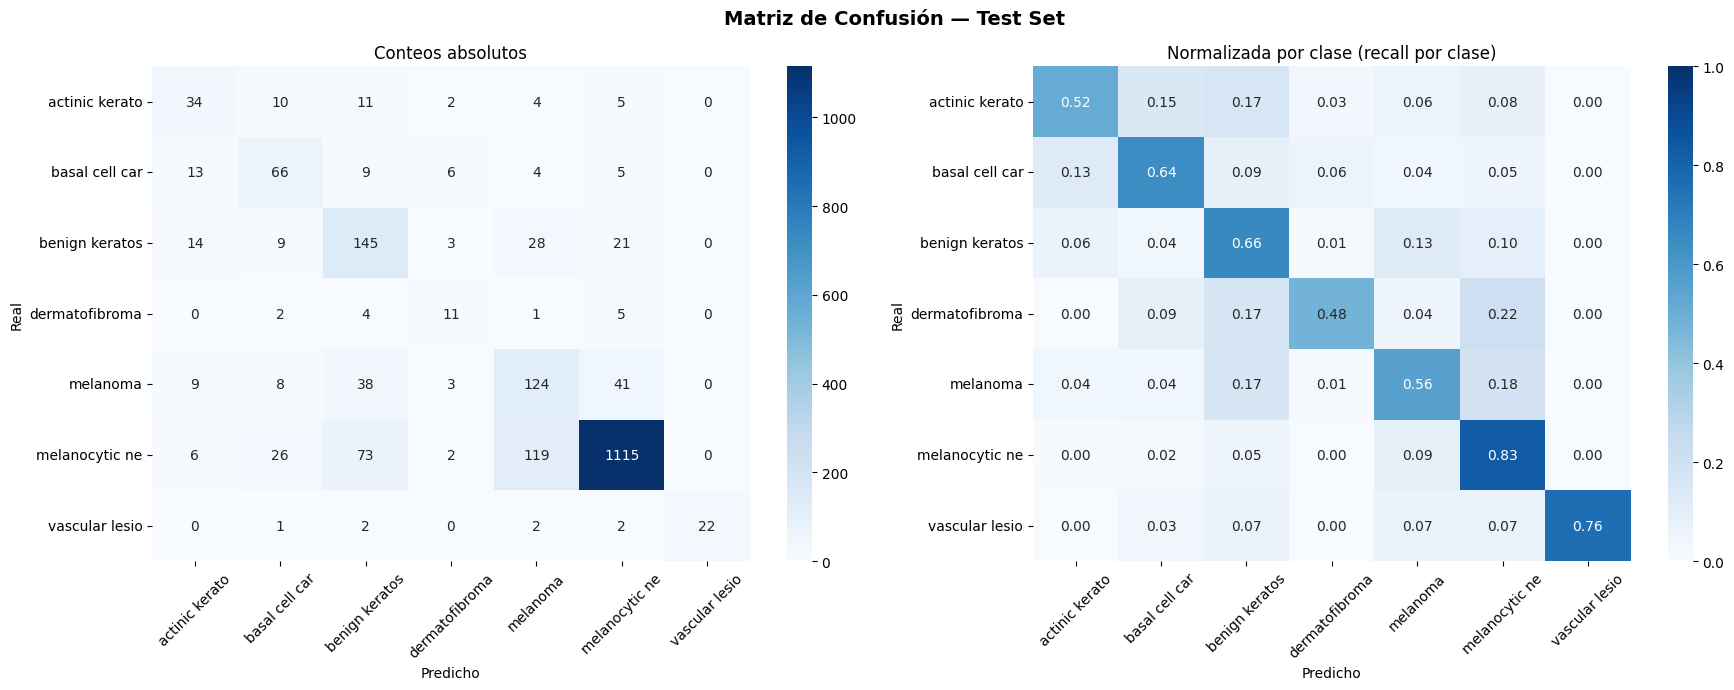

✅ Guardado: confusion_matrix.png

Reporte por clase:
                                                 precision    recall  f1-score   support

actinic keratoses and intraepithelial carcinoma       0.45      0.52      0.48        66
                           basal cell carcinoma       0.54      0.64      0.59       103
                  benign keratosis-like lesions       0.51      0.66      0.58       220
                                 dermatofibroma       0.41      0.48      0.44        23
                                       melanoma       0.44      0.56      0.49       223
                               melanocytic nevi       0.93      0.83      0.88      1341
                               vascular lesions       1.00      0.76      0.86        29

                                       accuracy                           0.76      2005
                                      macro avg       0.61      0.63      0.62      2005
                                   weighted avg       0

In [7]:
import seaborn as sns

cm = confusion_matrix(test_labels, test_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # normalizada por fila

short_names = [n[:14] for n in CLASS_NAMES]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Matriz de Confusión — Test Set', fontsize=14, fontweight='bold')

# Absoluta
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=short_names, yticklabels=short_names, ax=axes[0])
axes[0].set_title('Conteos absolutos')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicho')
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# Normalizada
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=short_names, yticklabels=short_names,
            vmin=0, vmax=1, ax=axes[1])
axes[1].set_title('Normalizada por clase (recall por clase)')
axes[1].set_ylabel('Real')
axes[1].set_xlabel('Predicho')
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: confusion_matrix.png')

# Métricas por clase
from sklearn.metrics import classification_report
print('\nReporte por clase:')
print(classification_report(test_labels, test_preds,
      target_names=CLASS_NAMES, zero_division=0))

## 11. Guardar artefactos para Fase 4

In [8]:
import pickle

# Guardar resultados del test para usar en Fase 4 (Grad-CAM)
artefactos = {
    'test_preds' : test_preds,
    'test_labels': test_labels,
    'test_probs' : test_probs,
    #'history'    : history,
    'test_acc'   : test_acc,
    'test_f1'    : test_f1,
    'test_auc'   : test_auc,
}

with open('test_results.pkl', 'wb') as f:
    pickle.dump(artefactos, f)

print('Archivos listos para Fase 4:')
print('  best_model.pth    — pesos del mejor modelo')
print('  test_results.pkl  — métricas y predicciones del test set')
print('  curvas_entrenamiento.png — para el reporte IEEE')
print('  confusion_matrix.png    — para el reporte IEEE')
print()
print('✅ Fase 3 completa — listo para Fase 4: Grad-CAM')

Archivos listos para Fase 4:
  best_model.pth    — pesos del mejor modelo
  test_results.pkl  — métricas y predicciones del test set
  curvas_entrenamiento.png — para el reporte IEEE
  confusion_matrix.png    — para el reporte IEEE

✅ Fase 3 completa — listo para Fase 4: Grad-CAM


## ✅ Resumen Fase 3

| Decisión | Justificación |
|----------|---------------|
| `AdamW` | Mejor regularización que Adam estándar (weight decay separado) |
| `CosineAnnealingLR` | Evita mínimos locales — baja LR suavemente |
| `CrossEntropyLoss(weight=...)` | Segunda línea de defensa contra desbalance |
| Gradient clipping (norm=1.0) | Evita explosión de gradientes en las fusiones no lineales |
| Early stopping en F1-Macro | Métrica más representativa para datasets desbalanceados |
| Checkpoint del mejor modelo | Evita sobreajuste al final del entrenamiento |

**Siguiente paso → Fase 4: Evaluación + Grad-CAM (XAI)**